In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/14986.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/3138.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/1700.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/16257.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/2863.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/771.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/12167.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/17643.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/6560.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/10162.jpg
/kaggl

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [3]:
train_ds = keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train",
    image_size=(224, 224),
    batch_size=32,
    shuffle=True
)

Found 14034 files belonging to 6 classes.


I0000 00:00:1787865814.112150      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787865814.115182      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [4]:
test_ds = keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test",
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

Found 3000 files belonging to 6 classes.


In [5]:
print(train_ds.class_names)


['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


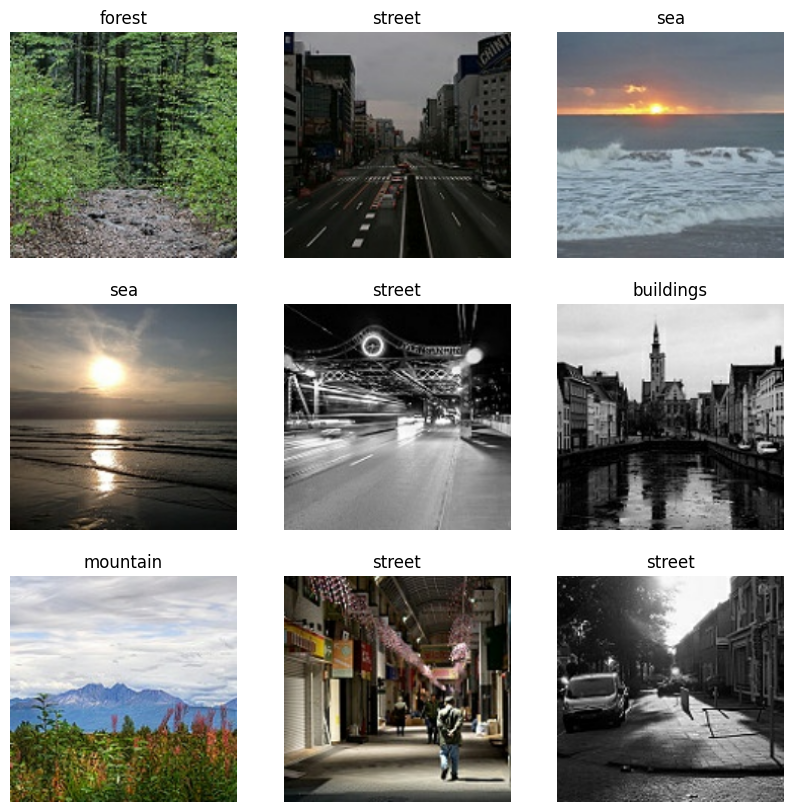

In [6]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(train_ds.class_names[labels[i]])
        plt.axis("off")

plt.show()

In [7]:
def normalize(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = train_ds.map(normalize)
test_ds = test_ds.map(normalize)

In [8]:
base_model = tf.keras.applications.MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
base_model.trainable = False

In [10]:
model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(6, activation='softmax')
])

In [11]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5
)

Epoch 1/5


2026-08-27 21:23:54.400563: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-27 21:23:54.539030: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1787865836.496425      78 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


437/439 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.8437 - loss: 0.4199

2026-08-27 21:24:25.671951: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-27 21:24:25.817368: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-27 21:24:25.954502: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.8439 - loss: 0.4194

2026-08-27 21:24:44.880726: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-27 21:24:45.018494: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


439/439 ━━━━━━━━━━━━━━━━━━━━ 68s 115ms/step - accuracy: 0.8868 - loss: 0.3091 - val_accuracy: 0.9153 - val_loss: 0.2320
Epoch 2/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.9210 - loss: 0.2189 - val_accuracy: 0.9147 - val_loss: 0.2443
Epoch 3/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.9304 - loss: 0.1841 - val_accuracy: 0.9140 - val_loss: 0.2355
Epoch 4/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.9391 - loss: 0.1581 - val_accuracy: 0.8977 - val_loss: 0.2768
Epoch 5/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.9463 - loss: 0.1354 - val_accuracy: 0.9117 - val_loss: 0.2490


In [13]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Accuracy:", test_accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9117 - loss: 0.2490
Test Accuracy: 0.9116666913032532


In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,752,212 (10.50 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 329,486 (1.26 MB)

In [15]:
def mobilenet_preprocess(image, label):
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image * 255.0)
    return image, label

train_ds = train_ds.map(mobilenet_preprocess)
test_ds = test_ds.map(mobilenet_preprocess)

In [16]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5
)

Epoch 1/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.9324 - loss: 0.1769 - val_accuracy: 0.8920 - val_loss: 0.3019
Epoch 2/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.9510 - loss: 0.1289 - val_accuracy: 0.9160 - val_loss: 0.2369
Epoch 3/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.9626 - loss: 0.1003 - val_accuracy: 0.9040 - val_loss: 0.2831
Epoch 4/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.9693 - loss: 0.0834 - val_accuracy: 0.9077 - val_loss: 0.2808
Epoch 5/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.9767 - loss: 0.0677 - val_accuracy: 0.9007 - val_loss: 0.3292


In [17]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Accuracy:", test_accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.9007 - loss: 0.3292
Test Accuracy: 0.9006666541099548


In [18]:
print("Trainable parameters:", model.trainable_variables)

for var in model.trainable_variables:
    print(var.name, var.shape)

Trainable parameters: [<Variable path=sequential/dense/kernel, shape=(1280, 128), dtype=float32, value=[[-0.09332016 -0.0245287   0.0112819  ... -0.09136969 -0.03444183
   0.06890827]
 [-0.04255805  0.00561706  0.01317315 ...  0.08152057  0.06817108
  -0.0316307 ]
 [-0.00522147 -0.0597014   0.11244227 ...  0.01492921 -0.03181066
   0.08656189]
 ...
 [ 0.0523368  -0.04502251  0.01266784 ...  0.19143362  0.00863959
  -0.15211867]
 [ 0.02678136 -0.0345702  -0.04961301 ...  0.08325813 -0.0114039
  -0.20339696]
 [ 0.00365475  0.02950781 -0.03301762 ...  0.0082841  -0.00820643
  -0.08504134]]>, <Variable path=sequential/dense/bias, shape=(128,), dtype=float32, value=[-0.03136355 -0.00702881 -0.01342998 -0.00720554  0.02843297 -0.01817186
 -0.01399629 -0.00649439 -0.00795707  0.00101074  0.02012193 -0.01069526
 -0.01348187 -0.02145105  0.01741901 -0.01326887 -0.02929501  0.01890453
  0.00882609 -0.01421741 -0.0006155  -0.0023505   0.02040397  0.0207192
 -0.01505131 -0.00562275 -0.0003028   0.

In [19]:
for images, labels in train_ds.take(1):
    print("Minimum:", tf.reduce_min(images).numpy())
    print("Maximum:", tf.reduce_max(images).numpy())

Minimum: -1.0
Maximum: 1.0


In [20]:
train_ds = keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train",
    image_size=(224, 224),
    batch_size=32,
    shuffle=True
)

test_ds = keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test",
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

Found 14034 files belonging to 6 classes.
Found 3000 files belonging to 6 classes.


In [21]:
def preprocess(image, label):
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label

train_ds = train_ds.map(preprocess)
test_ds = test_ds.map(preprocess)

In [22]:
for images, labels in train_ds.take(1):
    print("Minimum:", tf.reduce_min(images).numpy())
    print("Maximum:", tf.reduce_max(images).numpy())

Minimum: -1.0
Maximum: 1.0


In [23]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5
)

Epoch 1/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.9716 - loss: 0.0719 - val_accuracy: 0.9180 - val_loss: 0.2929
Epoch 2/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.9810 - loss: 0.0505 - val_accuracy: 0.9137 - val_loss: 0.3424
Epoch 3/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.9833 - loss: 0.0463 - val_accuracy: 0.9133 - val_loss: 0.3361
Epoch 4/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.9900 - loss: 0.0316 - val_accuracy: 0.9180 - val_loss: 0.3507
Epoch 5/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.9917 - loss: 0.0266 - val_accuracy: 0.9153 - val_loss: 0.3648


In [24]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Accuracy:", test_accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9153 - loss: 0.3648
Test Accuracy: 0.9153333306312561


In [25]:
base_model.trainable = True

In [26]:
for layer in base_model.layers[:-20]:
    layer.trainable = False

In [27]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [28]:
history_fine = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5
)

Epoch 1/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 44s 69ms/step - accuracy: 0.8890 - loss: 0.5183 - val_accuracy: 0.9057 - val_loss: 0.4839
Epoch 2/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.9318 - loss: 0.2397 - val_accuracy: 0.9063 - val_loss: 0.4675
Epoch 3/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.9493 - loss: 0.1642 - val_accuracy: 0.9043 - val_loss: 0.4581
Epoch 4/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.9560 - loss: 0.1320 - val_accuracy: 0.9050 - val_loss: 0.4319
Epoch 5/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.9671 - loss: 0.0944 - val_accuracy: 0.9073 - val_loss: 0.4312


In [29]:
test_loss_fine, test_accuracy_fine = model.evaluate(test_ds)

print("Fine-Tuned Test Accuracy:", test_accuracy_fine)

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9073 - loss: 0.4312
Fine-Tuned Test Accuracy: 0.9073333144187927


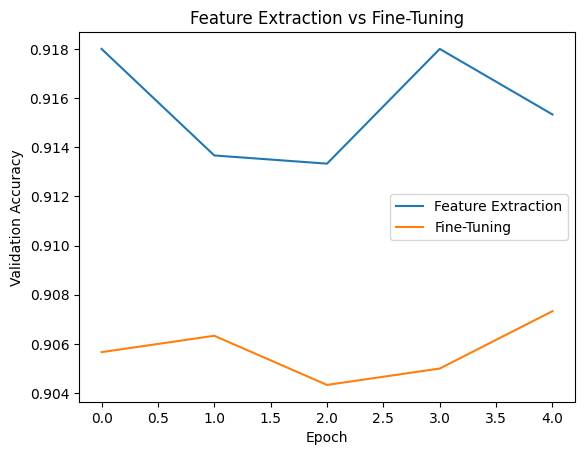

In [30]:
plt.plot(history.history['val_accuracy'], label='Feature Extraction')
plt.plot(history_fine.history['val_accuracy'], label='Fine-Tuning')

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Feature Extraction vs Fine-Tuning')
plt.legend()
plt.show()

In [31]:
import random
import os

class_names = [
    'buildings',
    'forest',
    'glacier',
    'mountain',
    'sea',
    'street'
]

class_name = random.choice(class_names)

folder = f"/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test/{class_name}"

image_name = random.choice(os.listdir(folder))

img_path = os.path.join(folder, image_name)

print("Actual class:", class_name)
print("Image:", image_name)
print("Image path:", img_path)

Actual class: forest
Image: 21699.jpg
Image path: /kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test/forest/21699.jpg


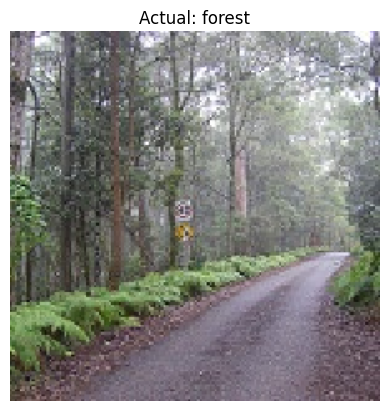

In [32]:
img = keras.utils.load_img(
    img_path,
    target_size=(224, 224)
)

plt.imshow(img)
plt.title(f"Actual: {class_name}")
plt.axis("off")
plt.show()

In [33]:
img_array = keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, axis=0)

img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)

prediction = model.predict(img_array)

predicted_class = class_names[tf.argmax(prediction[0]).numpy()]
confidence = tf.reduce_max(prediction[0]).numpy()

print("Actual class:", class_name)
print("Predicted class:", predicted_class)
print("Confidence:", confidence)

2026-08-27 21:30:17.426150: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-27 21:30:17.561827: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
Actual class: forest
Predicted class: forest
Confidence: 1.0
